# Chapter 4: Statistical Inference & Uncertainty

Topics covered:
1. Confidence Intervals
2. Bootstrapping
3. Hypothesis Testing Logic
4. p-values (correct interpretation)
5. Type I & Type II Errors
6. t-tests
7. Chi-square tests

In [14]:
from cmath import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


---
## 1. Confidence Intervals

**Formula (t-interval — σ unknown, which is almost always):**

$$\text{CI} = \bar{x} \pm t^* \cdot \frac{s}{\sqrt{n}}$$

| Symbol | Meaning |
|--------|---------|
| $\bar{x}$ | Sample mean — center of the interval |
| $t^*$ | Critical value (depends on confidence level and sample size) |
| $s$ | Sample standard deviation |
| $\sqrt{n}$ | Dividing by this shrinks uncertainty as sample grows |
| $\frac{s}{\sqrt{n}}$ | Standard error — how much sample means vary |

### Demo — What does "95% confidence" actually mean?

Run this cell as-is. It takes 100 different samples from the same population and builds a CI from each one.
Green = that interval captured the true mean. Red = it missed.
Count the red ones — there should be roughly 5.

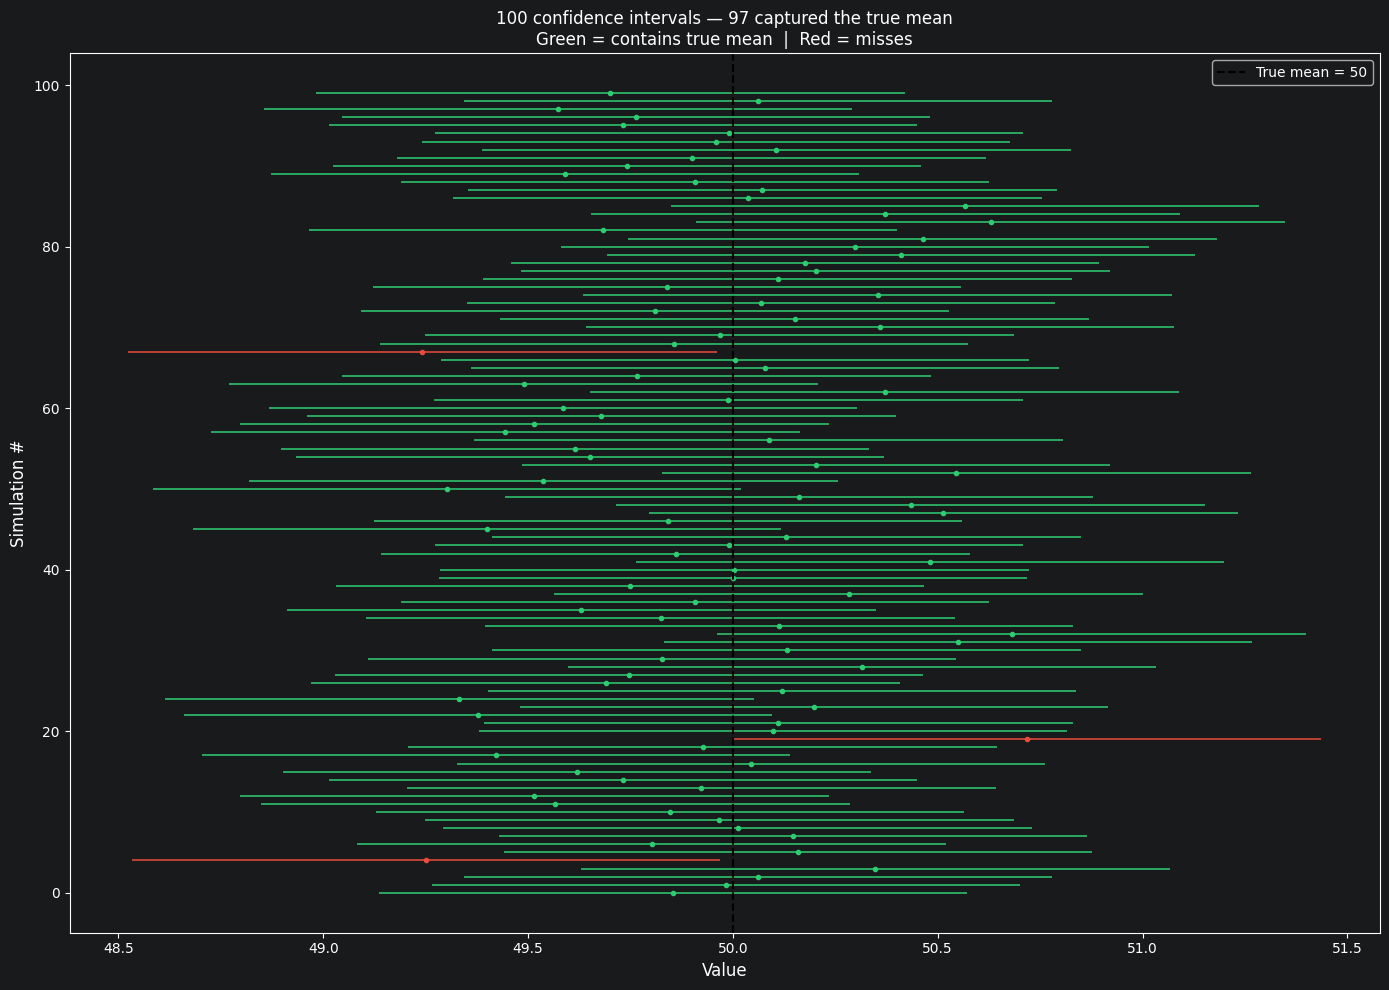

In [5]:
np.random.seed(7)
true_mean = 50
sigma = 2
n = 30
z_star = 1.96

captured = 0
fig, ax = plt.subplots(figsize=(14, 10))

for i in range(100):
    sample = np.random.normal(true_mean, sigma, n)
    x_bar = np.mean(sample)
    se = sigma / np.sqrt(n)
    lower = x_bar - z_star * se
    upper = x_bar + z_star * se
    contains = lower <= true_mean <= upper
    if contains:
        captured += 1
    color = '#2ecc71' if contains else '#e74c3c'
    ax.plot([lower, upper], [i, i], color=color, linewidth=1.4, alpha=0.8)
    ax.plot(x_bar, i, 'o', color=color, markersize=3)

ax.axvline(true_mean, color='black', linewidth=1.5, linestyle='--', label=f'True mean = {true_mean}')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Simulation #', fontsize=12)
ax.set_title(
    f'100 confidence intervals — {captured} captured the true mean\n'
    f'Green = contains true mean  |  Red = misses',
    fontsize=12
)
ax.legend()
plt.tight_layout()
plt.savefig('media/ci_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 1 — Compute a CI manually with NumPy

You run a speed test on 40 servers and record their response times in milliseconds:

```python
np.random.seed(1)
response_times = np.random.normal(loc=200, scale=30, size=40)
```

Compute a **95% confidence interval** for the mean response time using only NumPy:

1. Compute `x_bar` (sample mean) and `s` (sample std — use `ddof=1`)
2. Compute `n = len(response_times)`
3. Compute the standard error: `se = s / sqrt(n)`
4. Get the t* critical value: `t_star = stats.t.ppf(0.975, df=n-1)`
   - `0.975` because 95% CI puts 2.5% in each tail
   - `df=n-1` — degrees of freedom
5. Compute `lower = x_bar - t_star * se` and `upper = x_bar + t_star * se`
6. Print: sample mean, standard error, and the CI
7. The true mean is 200ms — did your interval capture it?

In [11]:
np.random.seed(1)
response_times = np.random.normal(loc=200, scale=30, size=40)
x_mean = np.mean(response_times)
x_std = np.std(response_times)
n = len(response_times)
se = x_std / np.sqrt(n)
t_star = stats.t.ppf(0.975, df=n-1)
ci_lower = x_mean - t_star * se
ci_upper = x_mean + t_star * se
print("Mean:", x_mean)
print("Std:", x_std)
print("SE:", se)
print("CI lower:", ci_lower)
print("CI upper:", ci_upper)

Mean: 197.31206076293375
Std: 28.93796257331982
SE: 4.575493628819896
CI lower: 188.0572513452337
CI upper: 206.5668701806338


### Task 2 — Shortcut with scipy

scipy has a one-liner that does everything from Task 1 in a single call:

```python
stats.t.interval(confidence, df, loc, scale)
```

Using the same `response_times` data:

1. Compute the CI using `stats.t.interval(0.95, df=n-1, loc=x_bar, scale=se)`
2. Print the result — it should exactly match Task 1
3. Now compute CIs at three confidence levels: 90%, 95%, 99%
4. Print all three and observe: which is widest? which is narrowest?
5. Write a comment explaining the tradeoff between confidence level and interval width

In [13]:
stats.t.interval(0.95, df=n-1, loc=x_mean, scale=se)

(np.float64(188.0572513452337), np.float64(206.5668701806338))

### Task 3 — Practical example: comparing two groups

You work at an e-commerce company. You want to know whether customers who use the mobile app
spend more per order than customers who use the website.

```python
np.random.seed(42)
app_orders     = np.random.normal(loc=85, scale=20, size=120)   # app users
website_orders = np.random.normal(loc=78, scale=25, size=95)    # website users
```

1. Compute a 95% CI for the mean order value of each group using `stats.t.interval()`
2. Print: group name | sample size | mean | CI
3. Visualize: draw a horizontal line for each group's CI with a dot at the mean
   - Put both groups on the same plot so you can compare them
   - Label axes and add a title
4. Do the two CIs overlap?
5. Write a comment: based on the CIs alone, can you say app users spend more? Why or why not?

In [17]:
np.random.seed(42)
app_orders     = np.random.normal(loc=85, scale=20, size=120)   # app users
website_orders = np.random.normal(loc=78, scale=25, size=95)    # website users

app_orders_n = len(app_orders)
app_orders_mean = np.mean(app_orders)
app_orders_std = np.std(app_orders)
app_orders_se = app_orders_std / np.sqrt(app_orders_n)
app_orders_ci = stats.t.interval(0.95, df=app_orders_n-1, loc=app_orders_mean, scale=app_orders_se)


website_orders_n = len(website_orders)
website_orders_mean = np.mean(website_orders)
website_orders_std = np.std(website_orders)
website_orders_se = website_orders_std / np.sqrt(website_orders_n)
website_orderss_ci = stats.t.interval(0.95, df=website_orders_n-1, loc=website_orders_mean, scale=website_orders_se)

print("Intervals for app orders: ", app_orders_ci)
print("Intervals for website orders: ", website_orderss_ci)

Intervals for app orders:  (np.float64(80.08542642345094), np.float64(86.74781137430955))
Intervals for website orders:  (np.float64(75.71305268145798), np.float64(85.80231819352628))


---
## 2. Bootstrapping

Bootstrapping estimates uncertainty around **any statistic** by resampling your data with replacement — no formulas needed.

**The process:**
1. Start with your one sample of n values
2. Draw n values **with replacement** (some repeat, some are skipped — that's intentional)
3. Compute your statistic (mean, median, std, anything) on the resample
4. Repeat 10,000 times → you now have a **bootstrap distribution** of your statistic
5. Take the 2.5th and 97.5th percentiles of that distribution → **95% bootstrap CI**

**Why it works:** your sample is the best approximation of the population you have.
Resampling from it mimics taking new samples from the real population.
The spread of the bootstrap distribution reflects your real uncertainty.

### Task 1 — Build a bootstrap CI manually with NumPy

You recorded the number of seconds users spend on a webpage (15 users):

```python
np.random.seed(5)
session_times = np.random.exponential(scale=45, size=15)   # skewed — not normal
```

Build a **95% bootstrap CI for the mean** using only NumPy:

1. Set `n_resamples = 10000`
2. Create an empty list `boot_means = []`
3. Loop 10,000 times:
   - Draw a resample: `resample = np.random.choice(session_times, size=len(session_times), replace=True)`
   - Compute its mean and append to `boot_means`
4. Convert `boot_means` to a numpy array
5. Compute the CI: `lower = np.percentile(boot_means, 2.5)` and `upper = np.percentile(boot_means, 97.5)`
6. Plot a histogram of `boot_means` and draw vertical lines at the lower and upper bounds
7. Print the original sample mean and the CI

In [6]:
np.random.seed(5)
session_times = np.random.exponential(scale=45, size=15)   # skewed — not normal
n_resemples = 10000
boot_means = []
for i in range(n_resemples):
    resample = np.random.choice(session_times, size=len(session_times), replace=True)
    boot_means.append(np.mean(resample))

boot_means = np.array(boot_means)
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)
print("Mean of original sample: ", np.mean(session_times))
print("95% CI: ", lower, '->', upper)

Mean of original sample:  41.086719722604485
95% CI:  24.789250928584888 -> 59.063504125075184


### Task 2 — Shortcut with scipy + bootstrap the median

`scipy.stats.bootstrap` does everything from Task 1 in one call.
More importantly, it works for **any statistic** — including the median, which has no formula-based CI.

Using the same `session_times` data:

1. Compute a bootstrap CI for the **mean** using scipy:
   ```python
   result = stats.bootstrap((session_times,), np.mean, n_resamples=10000,
                             confidence_level=0.95, random_state=1)
   print(result.confidence_interval)
   ```
   Verify it's close to Task 1.

2. Now swap `np.mean` for `np.median` — compute a bootstrap CI for the **median**
   (there is no formula for this — bootstrapping is the only clean way)

3. Print both CIs side by side: mean CI vs median CI
4. The data is right-skewed (exponential). Which is larger — the mean or the median?
   Does that match what you see in the two CIs?

In [10]:
result = stats.bootstrap((session_times,), np.mean, n_resamples=10000,confidence_level=0.95, random_state=1)
print(result.confidence_interval)

result = stats.bootstrap((session_times,), np.median, n_resamples=10000,confidence_level=0.95, random_state=1)
print(result.confidence_interval)

ConfidenceInterval(low=np.float64(25.886898021467506), high=np.float64(61.513683129801876))
ConfidenceInterval(low=np.float64(10.421008441474278), high=np.float64(60.3491718924863))


### Task 3 — Practical example: are delivery times getting faster?

A logistics company recorded delivery times (in hours) last year and this year:

```python
np.random.seed(99)
last_year = np.random.exponential(scale=48, size=40)   # avg ~48h
this_year = np.random.exponential(scale=41, size=40)   # avg ~41h — hopefully faster
```

Delivery times are right-skewed (most are fast, a few take very long) — so the **median** is a better measure than the mean here.

1. Compute a 95% bootstrap CI for the **median** of each year using `stats.bootstrap()`
2. Print: year | sample median | CI lower | CI upper
3. Visualize: plot both CIs as horizontal lines with a dot at each median on the same axes
   - Use different colors for each year and add a legend
4. Do the two CIs overlap?
5. Write a comment: based on the CIs, can you confidently say delivery times improved? Why or why not?

In [16]:
np.random.seed(99)
last_year = np.random.exponential(scale=48, size=40)   # avg ~48h
this_year = np.random.exponential(scale=41, size=40)   # avg ~41h — hopefully faster

last_median = stats.bootstrap((last_year,), np.median, n_resamples=10000,confidence_level=0.95, random_state=1)
print("Last year -> median: ", np.median(last_year), "| CI:  ", last_median.confidence_interval)

this_median = stats.bootstrap((this_year,), np.median, n_resamples=10000,confidence_level=0.95, random_state=1)
print("This year -> median: ", np.median(this_year), "| CI:  ", this_median.confidence_interval)

Last year -> median:  31.610408919998697 | CI:   ConfidenceInterval(low=np.float64(14.72707301709177), high=np.float64(44.85603792362331))
This year -> median:  32.3532014939118 | CI:   ConfidenceInterval(low=np.float64(19.423531791544733), high=np.float64(50.85920291654806))


---
## 3. t-tests

A t-test measures whether a difference between means is real or just random noise.
It produces a **t-statistic** (signal / noise) and a **p-value** (how surprising that t is under H₀).

| Test | When to use |
|------|-------------|
| **One-sample** | Compare one sample mean to a known fixed value |
| **Two-sample (independent)** | Compare means of two separate groups |
| **Paired** | Compare the same subjects measured twice (before/after) |

**Two-sample formula:**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

The denominator is the combined standard error of both groups — noise from both sides.

### Task 1 — Compute a two-sample t-test manually with NumPy

A pharmaceutical company tested recovery times (in days) for two groups of patients:

```python
np.random.seed(42)
standard_treatment = np.random.normal(loc=14, scale=3, size=40)   # known avg ~14 days
new_drug           = np.random.normal(loc=11, scale=3, size=40)   # new drug, avg ~11 days
```

Compute the t-statistic and p-value **from scratch** using only NumPy:

1. Compute the mean and std (`ddof=1`) of each group
2. Compute the combined standard error:
   `se = sqrt((s1² / n1) + (s2² / n2))`
3. Compute the t-statistic:
   `t = (mean1 - mean2) / se`
4. Compute degrees of freedom (simple approximation): `df = n1 + n2 - 2`
5. Compute the two-tailed p-value:
   `p = 2 * stats.t.sf(abs(t), df=df)`
   - `stats.t.sf` is the survival function — it gives the area in the tail beyond your t
   - Multiply by 2 for two-tailed test
6. Print: t-statistic, degrees of freedom, p-value
7. Is the result significant at α = 0.05? Write your interpretation as a comment

In [8]:
np.random.seed(42)
standard_treatment = np.random.normal(loc=14, scale=3, size=40)   # known avg ~14 days
new_drug           = np.random.normal(loc=11, scale=3, size=40)   # new drug, avg ~11

s_mean = np.mean(standard_treatment)
n_mean = np.mean(new_drug)
s_std = np.std(standard_treatment)
n_std = np.std(new_drug)
se = np.sqrt( (s_std**2 / len(standard_treatment) ) + ( n_std**2 / len( new_drug ) ) )
t = (s_mean - n_mean) / se
df = len(standard_treatment) + len(new_drug) - 2
p = 2 * stats.t.sf(abs(t), df = df)

print('t-statistic: ', t)
print('p-value: ', p)
print('Degrees of freedom: ', df)

t-statistic:  3.8281108339475787
p-value:  0.0002591775607525614
Degrees of freedom:  78


### Task 2 — All three t-tests with scipy

scipy has one-liners for all three types. This task covers all of them.

**One-sample** — a coffee machine is supposed to dispense exactly 200ml:
```python
np.random.seed(1)
cups = np.random.normal(loc=198, scale=5, size=30)
```
Use `stats.ttest_1samp(cups, popmean=200)` — is the machine underfilling?

**Two-sample** — same recovery time data from Task 1:
Use `stats.ttest_ind(standard_treatment, new_drug)` — verify it matches Task 1.

**Paired** — 20 patients, blood pressure measured before and after a drug:
```python
np.random.seed(7)
before = np.random.normal(loc=140, scale=10, size=20)
after  = before - np.random.normal(loc=6, scale=3, size=20)   # drug reduces BP by ~6
```
Use `stats.ttest_rel(before, after)` — did the drug significantly reduce blood pressure?

For each test:
1. Print the t-statistic and p-value
2. State H₀ and your conclusion in a comment

In [13]:
# your code here
np.random.seed(1)
cups = np.random.normal(loc=198, scale=5, size=30)
t_1 = stats.ttest_1samp(cups, popmean=200)
print('T1: ', t_1)

t_2 = stats.ttest_ind(standard_treatment, new_drug)
print('T2: ', t_2)

np.random.seed(7)
before = np.random.normal(loc=140, scale=10, size=20)
after  = before - np.random.normal(loc=6, scale=3, size=20)   # drug reduces BP by ~6
t_3 = stats.ttest_rel(before, after)
print('T3: ', t_3)


T1:  TtestResult(statistic=np.float64(-2.4544765204463315), pvalue=np.float64(0.020348982727854948), df=np.int64(29))
T2:  TtestResult(statistic=np.float64(3.779956579520743), pvalue=np.float64(0.0003053283796092925), df=np.float64(78.0))
T3:  TtestResult(statistic=np.float64(6.576206518564212), pvalue=np.float64(2.6996565427261256e-06), df=np.int64(19))


### Task 3 — Practical example: do men and women tip differently?

Load the tips dataset and run a real two-sample t-test on actual data:

```python
tips = sns.load_dataset('tips')
```

1. Split into two groups: `male_tips` and `female_tips` (use the `sex` column)
2. Print sample size, mean, and std for each group
3. Run `stats.ttest_ind()` — print t-statistic and p-value
4. Visualize:
   - Plot two boxplots side by side (one per group)
   - Add the p-value in the title
5. At α = 0.05, do men and women tip significantly differently?
6. Now look at the actual means — even if significant, is the difference large enough to matter in practice?
   Write your full interpretation as a comment (both statistical significance and practical importance)

In [21]:
# your code here
tips = sns.load_dataset('tips')
tips.head()
tips_male = tips[tips['sex'] == 'Male']['tip']
tips_female = tips[tips['sex'] == 'Female']['tip']
result = stats.ttest_ind(tips_male, tips_female)
print(result)
print(np.mean(tips_male), np.mean(tips_female))

TtestResult(statistic=np.float64(1.387859705421269), pvalue=np.float64(0.16645623503456752), df=np.float64(242.0))
3.0896178343949043 2.8334482758620685


---
## 4. Chi-square Tests

Chi-square tests work with **categorical data** — counts of how many observations fell into each category.

| Type | When to use | Where expected comes from |
|------|-------------|--------------------------|
| **Goodness of fit** | One variable — does its distribution match what I expect? | Your prior assumption |
| **Test of independence** | Two variables — are they related to each other? | Row and column totals |

**The formula (same for both):**
$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

- **O** = observed count (what you actually measured)
- **E** = expected count (what H₀ predicts)
- Large χ² → big gap between observed and expected → small p-value → reject H₀

### Task 1 — Compute both chi-square tests manually with NumPy

**Part A — Goodness of fit**

A factory produces M&Ms and claims the color distribution is:
- Red: 30%, Blue: 20%, Green: 20%, Yellow: 30%

You buy a bag and count: Red=42, Blue=18, Green=22, Yellow=38. Total = 120.

1. Compute the expected counts from the claimed proportions × 120
2. Compute χ² manually: `chi2 = np.sum((observed - expected)**2 / expected)`
3. Degrees of freedom = number of categories − 1
4. Compute the p-value: `p = stats.chi2.sf(chi2, df=df)`
5. Print χ², df, p-value. Does the bag match the claimed distribution?

**Part B — Test of independence**

Use the smoking/sickness data from the explanation:
```python
observed = np.array([[40, 60],   # smokers: sick, not sick
                     [20, 80]])  # non-smokers: sick, not sick
```

1. Compute row totals, column totals, grand total
2. Compute expected counts for each cell: `E = row_total * col_total / grand_total`
3. Compute χ² using the same formula
4. Degrees of freedom = (rows − 1) × (cols − 1)
5. Compute the p-value and print your conclusion

In [24]:
# your code here
observed = np.array([42,18,22,38])
expected = np.array([0.3*120, 0.2 * 120, 0.2 * 120, 0.3 * 120])
chi2 = np.sum((observed - expected)**2 / expected)
df = 4 - 1
p = stats.chi2.sf(chi2, df=df)
print("Chi Squared: ", chi2, 'P value: ', p)


observed = np.array([[40, 60],   # smokers: sick, not sick
                     [20, 80]])  # non-smokers: sick, not sick
row_total_smokers = 100
row_total_non_smokers = 100
column_total_sick = 60
column_total_not_sick = 140
grand_total = 200

e1 = (100 * 60) / 200
e2 = (100 * 140) / 200
e3 = (100 * 60) / 200
e4 = (100 * 140 )/ 200
expected = np.array([[e1,e2],[e3,e4]])
chi2 = np.sum((observed - expected)**2 / expected)
df = 4 - 1
p = stats.chi2.sf(chi2, df=df)
print("Chi Squared: ", chi2, 'P value: ', p)

Chi Squared:  2.7777777777777777 P value:  0.4271711671881252
Chi Squared:  9.523809523809524 P value:  0.02307941142802382


### Task 2 — Shortcut with scipy

scipy has one-liners for both types:
- Goodness of fit: `stats.chisquare(observed, f_exp=expected)`
- Test of independence: `stats.chi2_contingency(observed_table)`

1. Redo Part A from Task 1 using `stats.chisquare()` — verify it matches your manual result
2. Redo Part B from Task 1 using `stats.chi2_contingency()` — verify it matches
   - Note: `chi2_contingency` returns 4 values: `chi2, p, df, expected`
   - Print all four — compare the expected table scipy computed to what you calculated manually
3. Write a comment: what does the expected table from scipy tell you?

In [22]:
# your code here
observed = np.array([42,18,22,38])
expected = np.array([0.3*120, 0.2 * 120, 0.2 * 120, 0.3 * 120])
chi2 = stats.chisquare(observed, expected)
print("Chi Squared: ", chi2)


observed = np.array([[40, 60],   # smokers: sick, not sick
                     [20, 80]])  # non-smokers: sick, not sick
chi2 = stats.chi2_contingency(observed)
print("Chi Squared: ", chi2)


Chi Squared:  Power_divergenceResult(statistic=np.float64(2.7777777777777777), pvalue=np.float64(0.4271711671881252))
Chi Squared:  Chi2ContingencyResult(statistic=np.float64(8.595238095238095), pvalue=np.float64(0.0033704314473977136), dof=1, expected_freq=array([[30., 70.],
       [30., 70.]]))


### Task 3 — Practical example: did passenger class affect survival on the Titanic?

```python
titanic = sns.load_dataset('titanic')
```

1. Build a contingency table of `pclass` (1st, 2nd, 3rd) vs `survived` (0, 1):
   ```python
   table = pd.crosstab(titanic['pclass'], titanic['survived'])
   ```
2. Print the table — these are your observed counts
3. Run `stats.chi2_contingency(table)` — print χ², p-value, df, and expected counts
4. Visualize: plot a grouped bar chart showing survival counts for each passenger class
   - Each class on the x-axis, two bars per class (survived / did not survive)
   - Add p-value in the title
5. Look at the expected counts vs observed counts — which class deviates the most from independence?
6. Write your full interpretation as a comment:
   - Is the result statistically significant?
   - Which class had better/worse survival than expected?
   - What does this tell you about the Titanic?

In [27]:
# your code here
titanic = sns.load_dataset('titanic')
table = pd.crosstab(titanic['pclass'], titanic['survived'])
print(table)
stats.chi2_contingency(table)

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


Chi2ContingencyResult(statistic=np.float64(102.88898875696056), pvalue=np.float64(4.549251711298793e-23), dof=2, expected_freq=array([[133.09090909,  82.90909091],
       [113.37373737,  70.62626263],
       [302.53535354, 188.46464646]]))